In [43]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns


In [44]:
SUMMARY_FILE = Path("../results/aggregated/summary.tsv")  # adjust as needed
FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True)

# -- Figure constraints (Briefings in Bioinformatics) --
MAX_WIDTH = 6.5    # inches
MAX_HEIGHT = 8.0   # inches
MIN_DPI = 300

# -- Biological hierarchy: tasks --
CLF_TASKS = [
    "broad_activity",
    "gram_minus", "gram_plus",
    "species_ecoli", "species_saureus", "species_paeruginosa",
    "species_kpneumoniae", "species_abaumannii",
    "strain_ecoli25922",
    "strain_saureus25923", "strain_saureus33591", "strain_saureus43300",
    "strain_paeruginosa27853",
    "strain_kpneumoniae700603",
    "strain_abaumannii19606",
]
CLF_TASK_SHORT = [
    "General\nActivity",
    "Gram$-$", "Gram$+$",
    "EC", "SA", "PA", "KP", "AB",
    "EC\n25922", "SA\n25923", "SA\n33591", "SA\n43300",
    "PA\n27853", "KP\n700603", "AB\n19606",
]



TASK_GROUPS = [
    ("General", 0, 1),
    ("Gram", 1, 3),
    ("Species", 3, 8),
    ("Strain", 8, 15),
]

# -- Models (ordered by type, then roughly by overall performance) --
CLASSIFIERS = [
    "hydramp-amp-classifier",
    "ampscanner",
    "amplify",
    "sensexamp-classifier",
    "ampeppy",
    "ampredmfa",
    "mole-amp",
]
ACTIVITY_AWARE = ["hydramp-mic-classifier"]
REGRESSORS = [
    "mbc-attention", "ampredictor",
    "sensexamp-ecoli", "sensexamp-saureus",
    "deep-amp-cnn-gramneg", "deep-amp-cnn-grampos",
    "deep-amp-lstm-gramneg", "deep-amp-lstm-grampos",
    "apex-ecoli", "apex-saureus", "apex-min",
    "apex-abaumannii", "apex-paeruginosa", "apex-kpneumoniae",
]
ALL_CLF_MODELS = CLASSIFIERS + ACTIVITY_AWARE + REGRESSORS

MODEL_DISPLAY = {
    "hydramp-amp-classifier": "HydrAMP-AMP",
    "ampscanner": "AMP Scanner v2",
    "amplify": "AMPlify",
    "sensexamp-classifier": "sAMPpred-clf",
    "ampeppy": "amPEPpy",
    "ampredmfa": "AMPpred-MFA",
    "mole-amp": "MoLE-AMP",
    "hydramp-mic-classifier": "HydrAMP-MIC",
    "mbc-attention": "MBC-Attention",
    "ampredictor": "AMPredictor",
    "sensexamp-ecoli": "sAMPpred-EC",
    "sensexamp-saureus": "sAMPpred-SA",
    "deep-amp-cnn-gramneg": "Deep-AMP (CNN, G$-$)",
    "deep-amp-cnn-grampos": "Deep-AMP (CNN, G$+$)",
    "deep-amp-lstm-gramneg": "Deep-AMP (LSTM, G$-$)",
    "deep-amp-lstm-grampos": "Deep-AMP (LSTM, G$+$)",
    "apex-ecoli": "APEX-EC",
    "apex-saureus": "APEX-SA",
    "apex-min": "APEX-min",
    "apex-abaumannii": "APEX-AB",
    "apex-paeruginosa": "APEX-PA",
    "apex-kpneumoniae": "APEX-KP",
}

MODEL_GROUPS = [
    ("Classifiers", 0, len(CLASSIFIERS) + len(ACTIVITY_AWARE)),
    ("Regressors\n(binarized)", len(CLASSIFIERS) + len(ACTIVITY_AWARE), len(ALL_CLF_MODELS)),
]

# Regression panel
REG_MODELS = [
    "mbc-attention", "ampredictor",
    "sensexamp-ecoli", "sensexamp-saureus",
    "deep-amp-cnn-gramneg", "deep-amp-cnn-grampos",
    "deep-amp-lstm-gramneg", "deep-amp-lstm-grampos",
    "apex-ecoli", "apex-saureus", "apex-min",
    "apex-abaumannii", "apex-paeruginosa", "apex-kpneumoniae",
]
REG_TASKS = ["regression_ecoli25922", "regression_saureus25923"]
REG_TASK_LABELS = ["EC ATCC 25922", "SA ATCC 25923"]

In [51]:
df = pd.read_csv(SUMMARY_FILE, sep="\t")
df = df[df["variant"] != "example-model"].copy()


def build_matrix(df, models, tasks, metric):
    mat = np.full((len(models), len(tasks)), np.nan)
    for i, m in enumerate(models):
        for j, t in enumerate(tasks):
            row = df[(df["variant"] == m) & (df["task"] == t)]
            if not row.empty:
                val = row.iloc[0][metric]
                if pd.notna(val) and val != "":
                    try:
                        mat[i, j] = float(val)
                    except (ValueError, TypeError):
                        pass
    return mat


clf_mcc = build_matrix(df, ALL_CLF_MODELS, CLF_TASKS, "mcc")
clf_cov = build_matrix(df, ALL_CLF_MODELS, CLF_TASKS, "coverage")
reg_sp = build_matrix(df, REG_MODELS, REG_TASKS, "spearman")

# Dataset stats per task (from a full-coverage model)
task_stats = {}
for task in CLF_TASKS:
    rows = df[(df["task"] == task) & (df["coverage"] >= 0.99)]
    if rows.empty:
        rows = df[df["task"] == task].sort_values("coverage", ascending=False)
    r = rows.iloc[0]
    n_pos = int(float(r["n_positive"]))
    n_neg = int(float(r["n_negative"]))
    task_stats[task] = {"n": n_pos + n_neg, "n_pos": n_pos, "n_neg": n_neg,
                        "pos_frac": n_pos / (n_pos + n_neg)}

/tmp/ipykernel_378022/2823628563.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_a.set_xticklabels(CLF_TASK_SHORT, fontsize=5, rotation=45, ha="right")


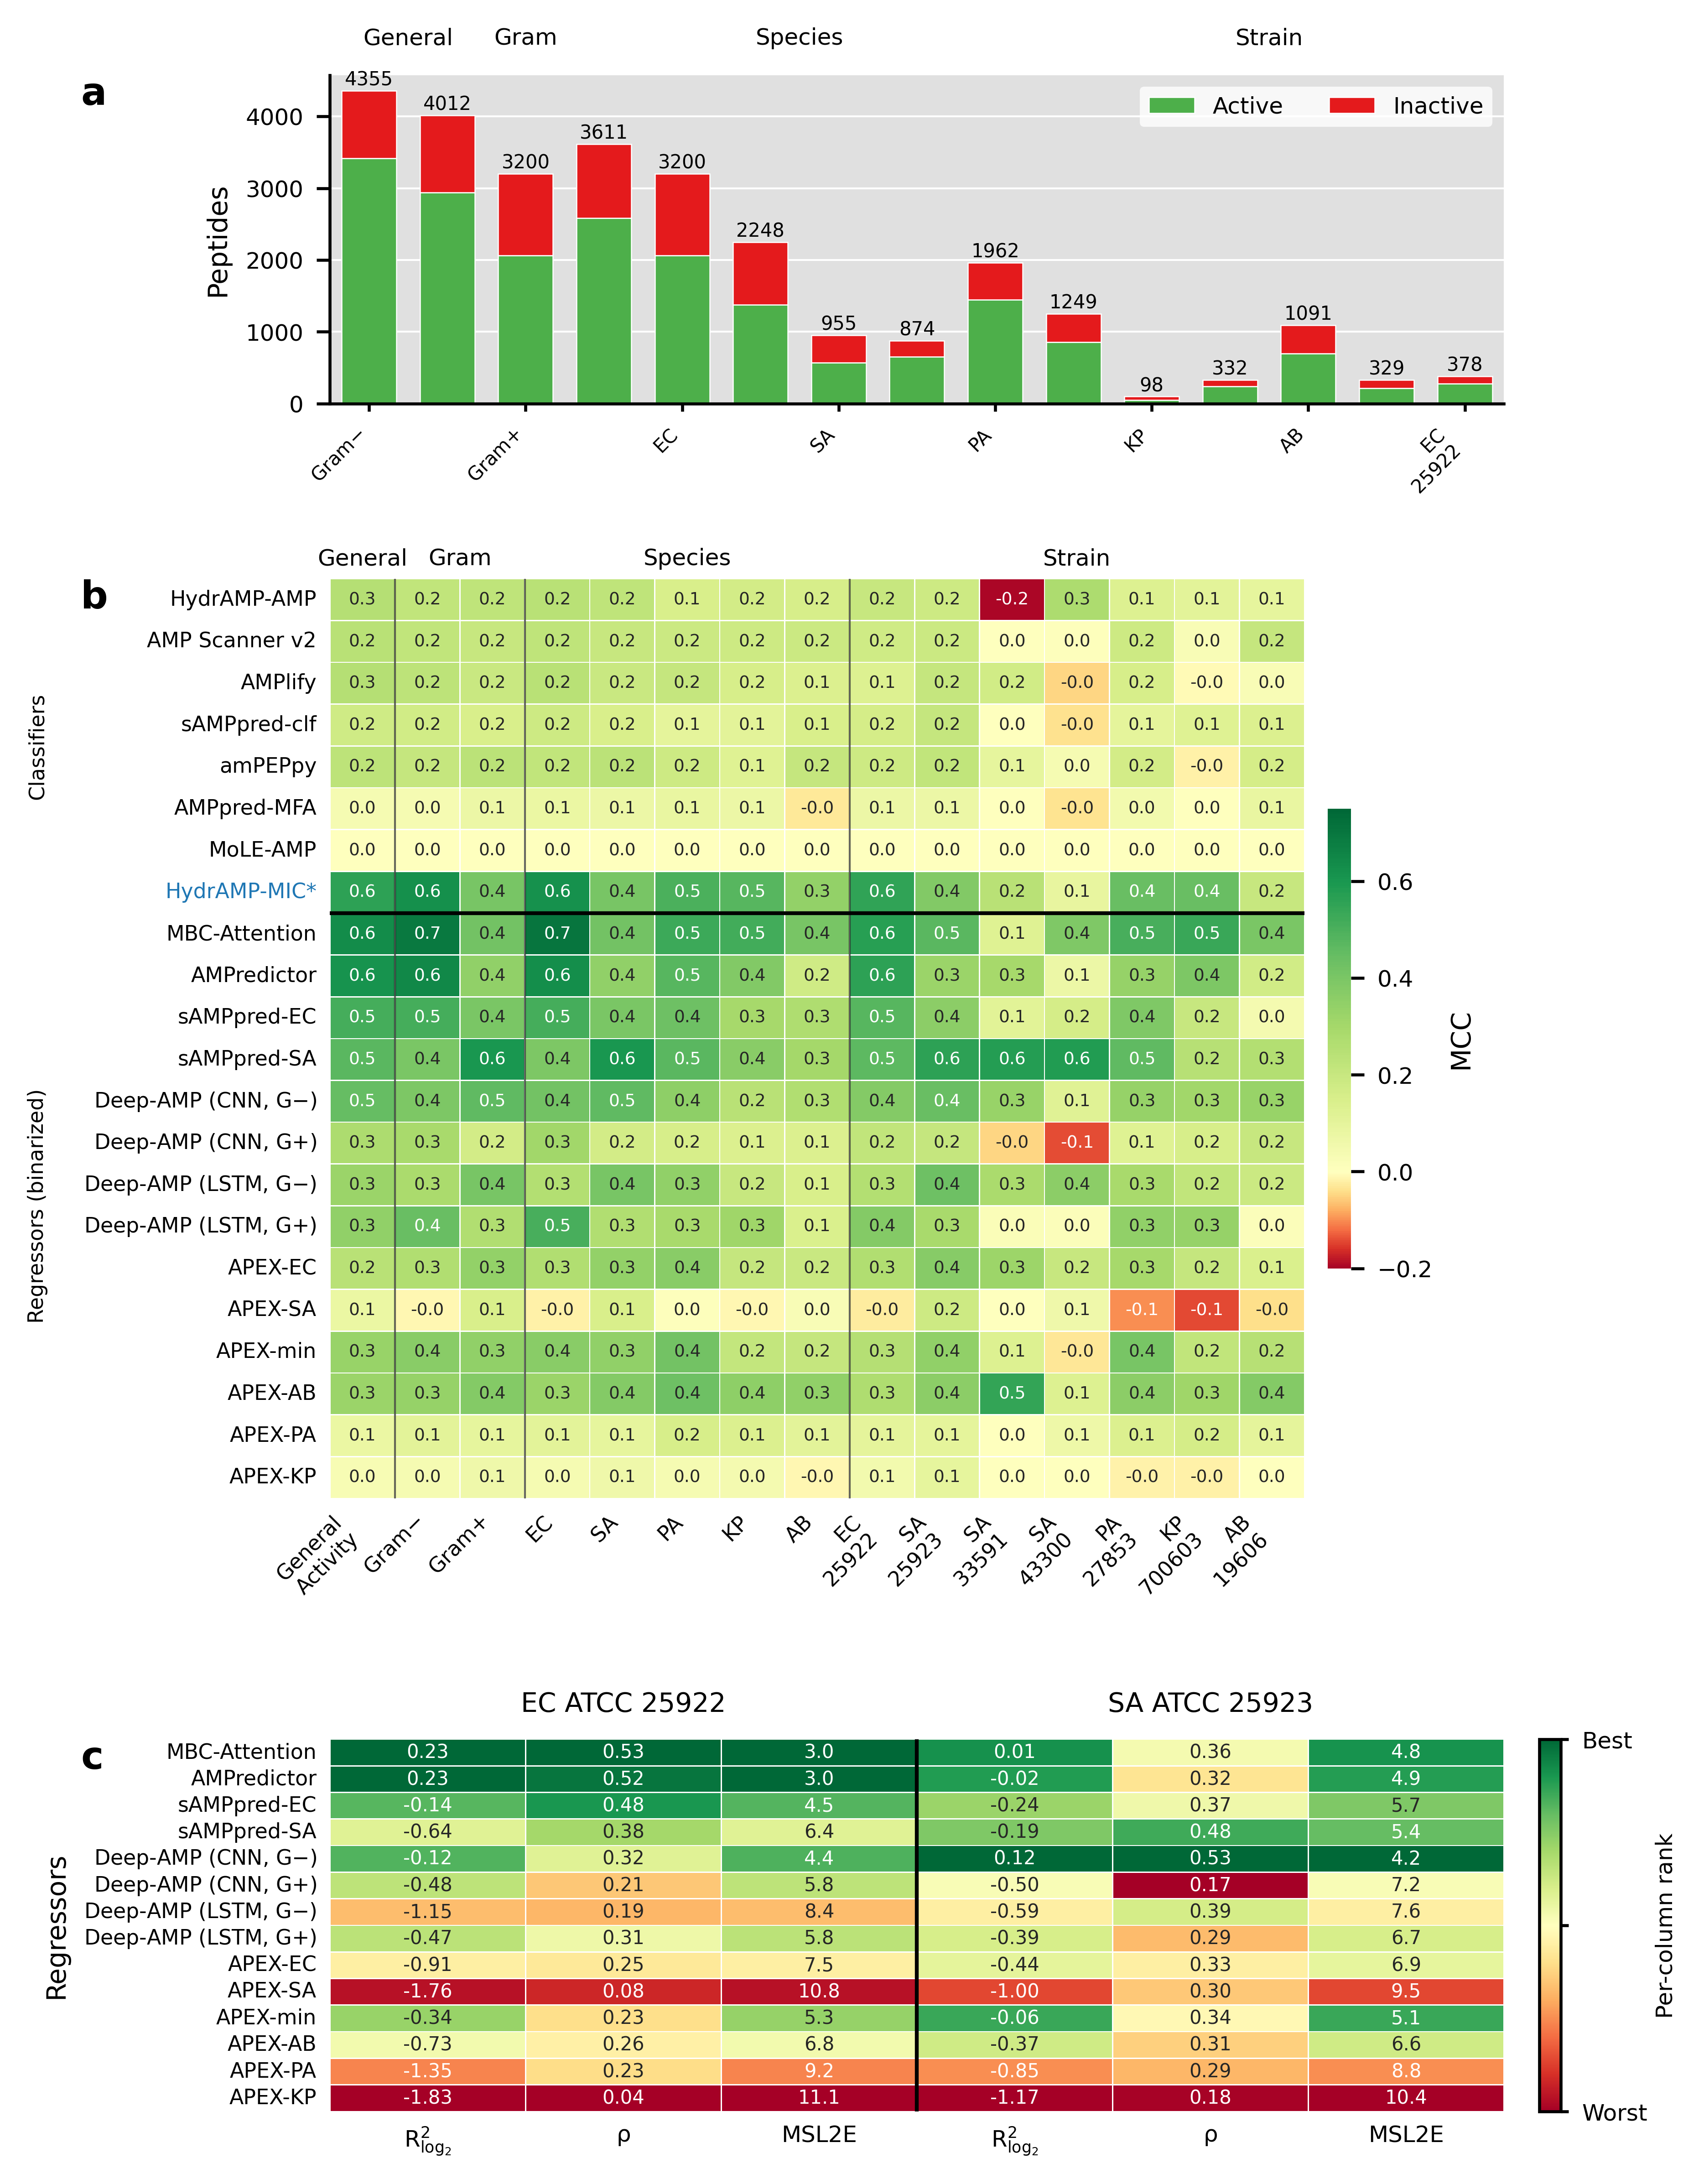

In [55]:
import matplotlib
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
matplotlib.rcParams["mathtext.default"] = "regular"

fig = plt.figure(figsize=(MAX_WIDTH, MAX_HEIGHT), dpi=600)

# Three separate GridSpecs with generous gaps
gs_a = gridspec.GridSpec(1, 1, left=0.22, right=0.88, top=0.97, bottom=0.82)
gs_b = gridspec.GridSpec(1, 1, left=0.22, right=0.88, top=0.74, bottom=0.32)
gs_c = gridspec.GridSpec(1, 1, left=0.22, right=0.88, top=0.21, bottom=0.04)

# ================================================================
# Panel A: Dataset sizes
# ================================================================
ax_a = fig.add_subplot(gs_a[0, 0])
ax_a.set_facecolor("#e0e0e0")

n_tasks = len(CLF_TASKS)
x = np.arange(n_tasks)
bar_w = 0.7

n_pos_vals = [task_stats[t]["n_pos"] for t in CLF_TASKS]
n_neg_vals = [task_stats[t]["n_neg"] for t in CLF_TASKS]
n_totals   = [task_stats[t]["n"] for t in CLF_TASKS]

ax_a.bar(x, n_pos_vals, bar_w, label="Active", color="#4daf4a",
         edgecolor="white", linewidth=0.3)
ax_a.bar(x, n_neg_vals, bar_w, bottom=n_pos_vals, label="Inactive",
         color="#e41a1c", edgecolor="white", linewidth=0.3)

for i, n in enumerate(n_totals):
    ax_a.text(i, n + 20, str(n), ha="center", va="bottom", fontsize=5)

ax_a.set_ylabel("Peptides", fontsize=7)
ax_a.set_xticklabels(CLF_TASK_SHORT, fontsize=5, rotation=45, ha="right")
ax_a.tick_params(axis="x", length=2)
# Force all labels visible (matplotlib auto-hides overlapping ones)
for lbl in ax_a.get_xticklabels():
    lbl.set_visible(True)

ax_a.tick_params(axis="x", length=2)
ax_a.tick_params(axis="y", labelsize=6)
ax_a.set_xlim(-0.5, n_tasks - 0.5)
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)

ax_a.yaxis.set_major_locator(plt.MultipleLocator(1000))
ax_a.yaxis.grid(True, color="white", linewidth=0.5)
ax_a.set_axisbelow(True)

ax_a.legend(fontsize=6, loc="upper right", frameon=True,
            facecolor="white", edgecolor="none", ncol=2)

# Task group brackets/labels above panel A
for label, start, end in TASK_GROUPS:
    mid = (start + end) / 2.0
    y_top = ax_a.get_ylim()[1] * 1.08
    ax_a.text(mid, y_top, label, ha="center", va="bottom", fontsize=6,
              clip_on=False)


# ================================================================
# Panel B: MCC heatmap
# ================================================================
ax_b = fig.add_subplot(gs_b[0, 0])

mask_b = np.isnan(clf_mcc) | ((~np.isnan(clf_cov)) & (clf_cov < 0.5))
norm_b = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.75)

sns.heatmap(
    clf_mcc,
    mask=mask_b,
    ax=ax_b,
    cmap="RdYlGn",
    norm=norm_b,
    linewidths=0.2,
    linecolor="white",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 4.5},
    cbar_kws={"shrink": 0.5, "aspect": 20, "pad": 0.02},
    xticklabels=CLF_TASK_SHORT,
    yticklabels=[MODEL_DISPLAY.get(m, m) for m in ALL_CLF_MODELS],
)

# Grey fill for masked cells
for i in range(len(ALL_CLF_MODELS)):
    for j in range(n_tasks):
        if mask_b[i, j]:
            ax_b.add_patch(mpatches.Rectangle(
                (j, i), 1, 1, facecolor="#e8e8e8", edgecolor="white",
                linewidth=0.2))

# Only bottom x-ticks
ax_b.set_xticklabels(ax_b.get_xticklabels(), rotation=45, ha="right",
                      fontsize=5.5)
ax_b.xaxis.set_ticks_position("bottom")
ax_b.set_yticklabels(ax_b.get_yticklabels(), fontsize=5.5)
ax_b.tick_params(axis="both", length=0)

# After setting yticklabels on ax_b, color the HydrAMP-MIC label:
ytick_labels = ax_b.get_yticklabels()
for lbl in ytick_labels:
    if "HydrAMP-MIC" in lbl.get_text():
        lbl.set_color("#1f77b4")      # matplotlib default blue
        lbl.set_text(lbl.get_text() + "*")
ax_b.set_yticklabels(ytick_labels)

# Colorbar
cbar_b = ax_b.collections[0].colorbar
cbar_b.ax.tick_params(labelsize=6)
cbar_b.set_label("MCC", fontsize=7)

n_models = len(ALL_CLF_MODELS)

# Model group separator
for label, start, end in MODEL_GROUPS:
    if start > 0:
        ax_b.axhline(y=start, color="black", linewidth=1.0)

# Task group separators (vertical)
for _, _, end in TASK_GROUPS[:-1]:
    ax_b.axvline(x=end, color="black", linewidth=0.5, alpha=0.6)

# Task group labels above heatmap
for label, start, end in TASK_GROUPS:
    mid = (start + end) / 2.0 / n_tasks
    ax_b.text(mid, 1.01, label, ha="center", va="bottom", fontsize=6,
              transform=ax_b.transAxes)

# Model group labels in far-left margin
for label, start, end in MODEL_GROUPS:
    mid_frac = 1.0 - (start + end) / 2.0 / n_models
    ax_b.text(
        -0.3, mid_frac, label.replace("\n", " "),
        ha="center", va="center", fontsize=5.5, rotation=90,
        transform=ax_b.transAxes, clip_on=False,
    )

# ================================================================
# Panel C: Regression heatmap
# ================================================================
ax_c = fig.add_subplot(gs_c[0, 0])

REG_METRICS = ["r2_log2", "spearman", "msl2e"]
REG_METRIC_LABELS = ["$R^2_{\\log_2}$", "$\\rho$", "MSL2E"]
HIGHER_IS_BETTER = [True, True, False]

n_orgs = len(REG_TASKS)
n_mets = len(REG_METRICS)
reg_raw = np.full((len(REG_MODELS), n_orgs * n_mets), np.nan)

for i, m in enumerate(REG_MODELS):
    for j, t in enumerate(REG_TASKS):
        for k, metric in enumerate(REG_METRICS):
            row = df[(df["variant"] == m) & (df["task"] == t)]
            if not row.empty:
                val = row.iloc[0][metric]
                if pd.notna(val) and val != "":
                    try:
                        reg_raw[i, j * n_mets + k] = float(val)
                    except (ValueError, TypeError):
                        pass

reg_norm = reg_raw.copy()
for col_idx in range(reg_raw.shape[1]):
    metric_idx = col_idx % n_mets
    col = reg_raw[:, col_idx]
    valid = col[~np.isnan(col)]
    if len(valid) > 0:
        vmin, vmax = valid.min(), valid.max()
        if vmax > vmin:
            reg_norm[:, col_idx] = (col - vmin) / (vmax - vmin)
            if not HIGHER_IS_BETTER[metric_idx]:
                reg_norm[:, col_idx] = 1.0 - reg_norm[:, col_idx]
        else:
            reg_norm[:, col_idx] = 0.5

annot_text = np.full(reg_raw.shape, "", dtype=object)
for i in range(reg_raw.shape[0]):
    for j in range(reg_raw.shape[1]):
        if not np.isnan(reg_raw[i, j]):
            metric_idx = j % n_mets
            if metric_idx == 2:
                annot_text[i, j] = f"{reg_raw[i, j]:.1f}"
            else:
                annot_text[i, j] = f"{reg_raw[i, j]:.2f}"

mask_c = np.isnan(reg_raw)

col_labels = []
for _ in REG_TASK_LABELS:
    for m_label in REG_METRIC_LABELS:
        col_labels.append(m_label)

sns.heatmap(
    reg_norm,
    mask=mask_c,
    ax=ax_c,
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.2,
    linecolor="white",
    annot=annot_text,
    fmt="",
    annot_kws={"size": 5},
    cbar=False,
    xticklabels=col_labels,
    yticklabels=[MODEL_DISPLAY.get(m, m) for m in REG_MODELS],
)

ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=0, ha="center",
                      fontsize=6)
ax_c.set_yticklabels(ax_c.get_yticklabels(), fontsize=5.5)
ax_c.tick_params(axis="both", length=0)
ax_c.set_ylabel("Regressors", fontsize=7)

ax_c.axvline(x=n_mets, color="black", linewidth=1.0)

# Organism labels above panel C
for idx, org_label in enumerate(REG_TASK_LABELS):
    mid_x = (idx * n_mets + n_mets / 2.0) / (n_mets * n_orgs)
    ax_c.text(mid_x, 1.06, org_label, ha="center", va="bottom",
              fontsize=7, transform=ax_c.transAxes)

# Colorbar for panel C
ax_c_pos = ax_c.get_position()
cax = fig.add_axes([
    ax_c_pos.x1 + 0.02,
    ax_c_pos.y0,
    0.012,
    ax_c_pos.height,
])
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(0, 1))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.set_ticks([0, 0.5, 1])
cax.set_yticklabels(["Worst", "", "Best"])
cax.tick_params(labelsize=6, size=2)
cb.set_label("Per-column rank", fontsize=6, labelpad=2)

# Remove the individual ax_a.text / ax_b.text / ax_c.text calls for "a", "b", "c"
# and replace with these at the end (before save):

# Get top y of each panel for letter placement
a_top = gs_a.get_grid_positions(fig)[0][0]  # or just hardcode from your GridSpec
fig.text(0.08, 0.97, "a", fontsize=10, fontweight="bold", va="top")
fig.text(0.08, 0.74, "b", fontsize=10, fontweight="bold", va="top")
fig.text(0.08, 0.21, "c", fontsize=10, fontweight="bold", va="top")

# ================================================================
# Save
# ================================================================
fig.savefig(FIGURE_DIR / "figure3_hierarchy.pdf", bbox_inches="tight", dpi=600)
fig.savefig(FIGURE_DIR / "figure3_hierarchy.png", bbox_inches="tight", dpi=600)
plt.show()